In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
from pathlib import Path

# Notebook is inside the notebooks folder,
# so go one level up to the project root.
PROJECT_ROOT = Path.cwd().parent

# Processed data folder
DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data directory:")
print(DATA_DIR)

print("\nData directory exists:", DATA_DIR.exists())

Project root:
e:\SDL\Projects\AI project\ticket-booking-analytics

Processed data directory:
e:\SDL\Projects\AI project\ticket-booking-analytics\data\processed

Data directory exists: True


In [6]:
customers = pd.read_csv(
    DATA_DIR / "customers_clean.csv"
)

operators = pd.read_csv(
    DATA_DIR / "operators_clean.csv"
)

routes = pd.read_csv(
    DATA_DIR / "routes_clean.csv"
)

trips = pd.read_csv(
    DATA_DIR / "trips_clean.csv"
)

bookings = pd.read_csv(
    DATA_DIR / "bookings_clean.csv"
)

print("Datasets loaded successfully!")


Datasets loaded successfully!


In [7]:
print("Customers :", len(customers))
print("Operators :", len(operators))
print("Routes    :", len(routes))
print("Trips     :", len(trips))
print("Bookings  :", len(bookings))

Customers : 5000
Operators : 20
Routes    : 30
Trips     : 300
Bookings  : 20000


In [9]:
customers.head()
operators.head()
routes.head()
routes.head()
bookings.head()

,booking_id,customer_id,trip_id,booking_date,travel_date,seat_count,ticket_price,total_amount,payment_method,booking_status
0,BOOK000001,CUST04855,TRIP00295,2025-09-15,2025-10-02,1,434.16,434.16,CARD,CONFIRMED
1,BOOK000002,CUST01610,TRIP00276,2025-11-08,2025-12-19,2,859.88,1719.76,CASH,PENDING
2,BOOK000003,CUST04709,TRIP00150,2025-09-06,2025-10-13,3,571.53,1714.59,CARD,CONFIRMED
3,BOOK000004,CUST03970,TRIP00218,2025-12-29,2026-02-24,2,1004.20,2008.40,NETBANKING,CANCELLED
4,BOOK000005,CUST03541,TRIP00065,2024-12-17,2025-01-17,2,935.96,1871.92,WALLET,CONFIRMED


In [10]:
print("CUSTOMERS")
print(customers.shape)

print("\nOPERATORS")
print(operators.shape)

print("\nROUTES")
print(routes.shape)

print("\nTRIPS")
print(trips.shape)

print("\nBOOKINGS")
print(bookings.shape)

CUSTOMERS
(5000, 6)

OPERATORS
(20, 3)

ROUTES
(30, 6)

TRIPS
(300, 7)

BOOKINGS
(20000, 10)


In [11]:
customers.info()
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5000 non-null   object
 1   customer_name      5000 non-null   object
 2   gender             5000 non-null   object
 3   age                5000 non-null   int64 
 4   city               5000 non-null   object
 5   registration_date  5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   booking_id      20000 non-null  object 
 1   customer_id     20000 non-null  object 
 2   trip_id         20000 non-null  object 
 3   booking_date    20000 non-null  object 
 4   travel_date     20000 non-null  object 
 5   seat_count      20000 non-null  int64

In [12]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

trips["departure_datetime"] = pd.to_datetime(
    trips["departure_datetime"]
)

trips["arrival_datetime"] = pd.to_datetime(
    trips["arrival_datetime"]
)

bookings["booking_date"] = pd.to_datetime(
    bookings["booking_date"]
)

bookings["travel_date"] = pd.to_datetime(
    bookings["travel_date"]
)

print("Date conversion completed")

Date conversion completed


In [13]:
customers.describe()

,age,registration_date
count,5000.000000,5000
mean,41.543600,2025-03-29 19:25:14.880000
min,18.000000,2024-01-01 00:00:00
25%,29.000000,2024-08-18 00:00:00
50%,42.000000,2025-03-26 00:00:00
75%,54.000000,2025-11-08 00:00:00
max,65.000000,2026-06-19 00:00:00
std,13.881262,NaN


In [18]:
bookings["ticket_price"].mean()


np.float64(1013.463567)

In [19]:
bookings["total_amount"].mean()


np.float64(2160.6137905)

In [20]:
bookings["total_amount"].sum()


np.float64(43212275.81)

In [21]:
bookings["seat_count"].sum()

np.int64(42765)

In [22]:
total_bookings = len(bookings)

total_tickets = bookings["seat_count"].sum()

total_revenue = bookings["total_amount"].sum()

average_ticket_price = bookings["ticket_price"].mean()

average_booking_value = bookings["total_amount"].mean()

confirmed_bookings = (
    bookings["booking_status"] == "CONFIRMED"
).sum()

cancelled_bookings = (
    bookings["booking_status"] == "CANCELLED"
).sum()

pending_bookings = (
    bookings["booking_status"] == "PENDING"
).sum()


print("=" * 60)
print("TICKET BOOKING KPI SUMMARY")
print("=" * 60)

print(f"Total Bookings          : {total_bookings:,}")
print(f"Total Tickets           : {total_tickets:,}")
print(f"Total Revenue           : ₹{total_revenue:,.2f}")
print(f"Average Ticket Price    : ₹{average_ticket_price:,.2f}")
print(f"Average Booking Value   : ₹{average_booking_value:,.2f}")
print(f"Confirmed Bookings      : {confirmed_bookings:,}")
print(f"Cancelled Bookings      : {cancelled_bookings:,}")
print(f"Pending Bookings        : {pending_bookings:,}")

TICKET BOOKING KPI SUMMARY
Total Bookings          : 20,000
Total Tickets           : 42,765
Total Revenue           : ₹43,212,275.81
Average Ticket Price    : ₹1,013.46
Average Booking Value   : ₹2,160.61
Confirmed Bookings      : 16,334
Cancelled Bookings      : 2,653
Pending Bookings        : 1,013


In [23]:
status_counts = bookings[
    "booking_status"
].value_counts()

status_counts

booking_status
CONFIRMED    16334
CANCELLED     2653
PENDING       1013
Name: count, dtype: int64

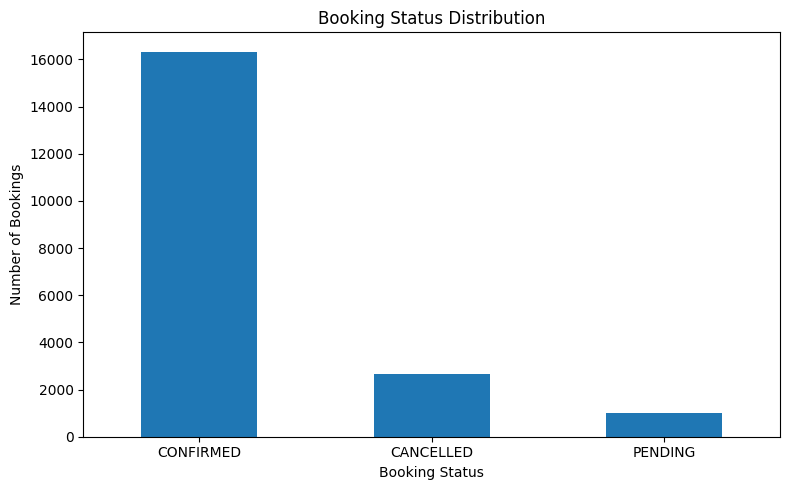

In [24]:
plt.figure(figsize=(8, 5))

status_counts.plot(
    kind="bar"
)

plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [25]:
payment_counts = bookings[
    "payment_method"
].value_counts()

payment_counts

payment_method
CASH          4096
WALLET        4051
UPI           3973
CARD          3947
NETBANKING    3933
Name: count, dtype: int64

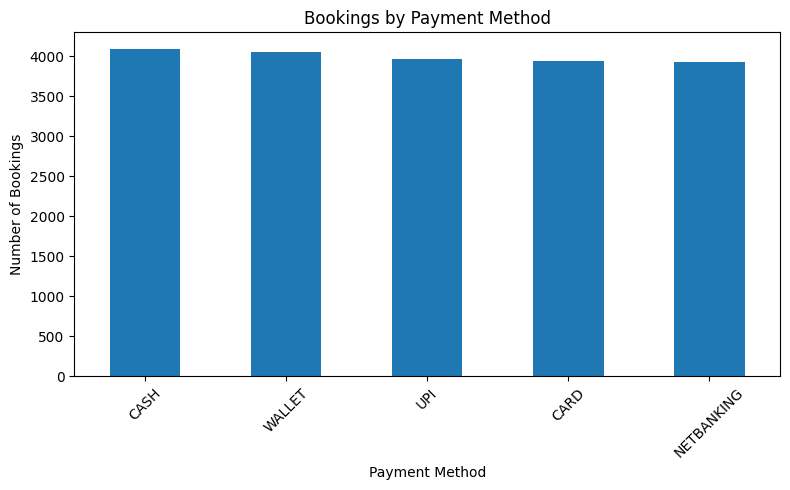

In [26]:
plt.figure(figsize=(8, 5))

payment_counts.plot(
    kind="bar"
)

plt.title("Bookings by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [27]:
booking_trip = bookings.merge(
    trips[
        [
            "trip_id",
            "vehicle_type",
            "route_id",
            "operator_id"
        ]
    ],
    on="trip_id",
    how="left"
)

In [28]:
booking_trip.head()

,booking_id,customer_id,trip_id,booking_date,travel_date,seat_count,ticket_price,total_amount,payment_method,booking_status,vehicle_type,route_id,operator_id
0,BOOK000001,CUST04855,TRIP00295,2025-09-15,2025-10-02,1,434.16,434.16,CARD,CONFIRMED,BIKE,R030,OP006
1,BOOK000002,CUST01610,TRIP00276,2025-11-08,2025-12-19,2,859.88,1719.76,CASH,PENDING,AUTO,R010,OP003
2,BOOK000003,CUST04709,TRIP00150,2025-09-06,2025-10-13,3,571.53,1714.59,CARD,CONFIRMED,CAB,R017,OP018
3,BOOK000004,CUST03970,TRIP00218,2025-12-29,2026-02-24,2,1004.20,2008.40,NETBANKING,CANCELLED,CAB,R002,OP011
4,BOOK000005,CUST03541,TRIP00065,2024-12-17,2025-01-17,2,935.96,1871.92,WALLET,CONFIRMED,CAB,R023,OP016


In [29]:
vehicle_bookings = booking_trip[
    "vehicle_type"
].value_counts()

vehicle_bookings

vehicle_type
CAB     5334
BUS     5052
BIKE    4891
AUTO    4723
Name: count, dtype: int64

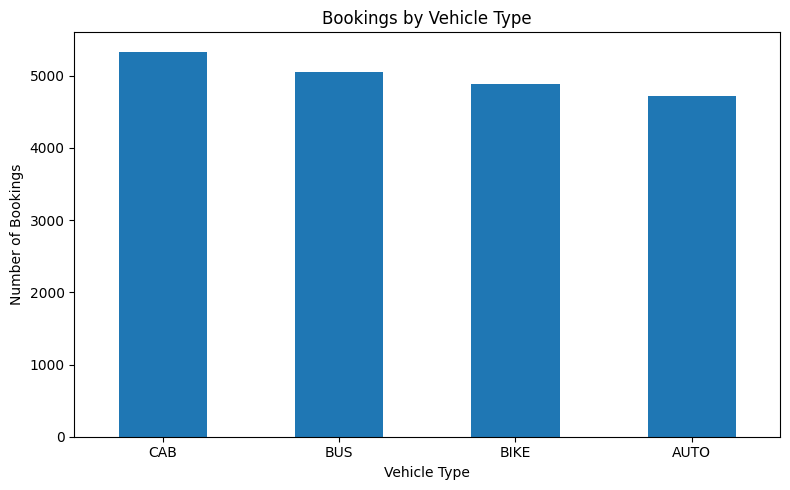

In [30]:
plt.figure(figsize=(8, 5))

vehicle_bookings.plot(
    kind="bar"
)

plt.title("Bookings by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [31]:
revenue_by_vehicle = (
    booking_trip
    .groupby("vehicle_type")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_vehicle

vehicle_type
CAB     14648662.50
BUS     14506314.00
AUTO     8981690.27
BIKE     5075609.04
Name: total_amount, dtype: float64

In [32]:
booking_trip_route = booking_trip.merge(
    routes[
        [
            "route_id",
            "route_name",
            "source",
            "destination"
        ]
    ],
    on="route_id",
    how="left"
)

In [33]:
top_routes = (
    booking_trip_route
    .groupby("route_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_routes

route_name
Tirunelveli To Coimbatore    1079
Tirunelveli To Madurai       1053
Hyderabad To Madurai         1020
Bengaluru To Erode           1014
Thanjavur To Pondicherry      887
Bengaluru To Thanjavur        860
Vellore To Pondicherry        807
Coimbatore To Chennai         766
Bengaluru To Trichy           755
Coimbatore To Tirunelveli     738
dtype: int64

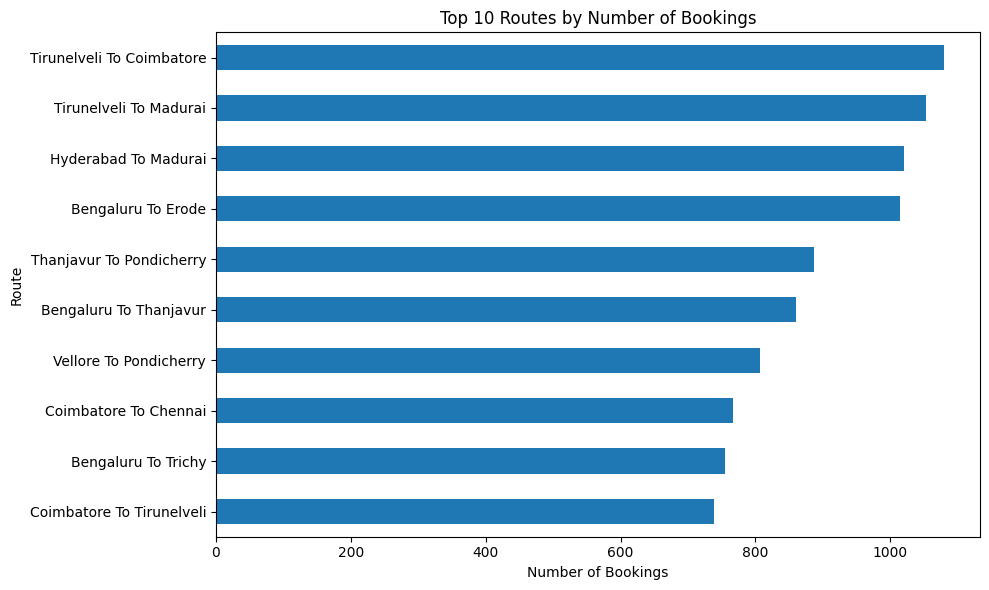

In [34]:
plt.figure(figsize=(10, 6))

top_routes.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Routes by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Route")

plt.tight_layout()

plt.show()

In [35]:
top_revenue_routes = (
    booking_trip_route
    .groupby("route_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_routes

route_name
Vellore To Pondicherry     3204559.00
Bengaluru To Thanjavur     3150928.19
Tirunelveli To Madurai     2689305.62
Bengaluru To Madurai       2504519.95
Madurai To Erode           2295753.04
Bengaluru To Erode         2002471.65
Trichy To Erode            1850969.21
Bengaluru To Trichy        1835876.76
Thanjavur To Coimbatore    1810466.05
Hyderabad To Madurai       1721741.34
Name: total_amount, dtype: float64

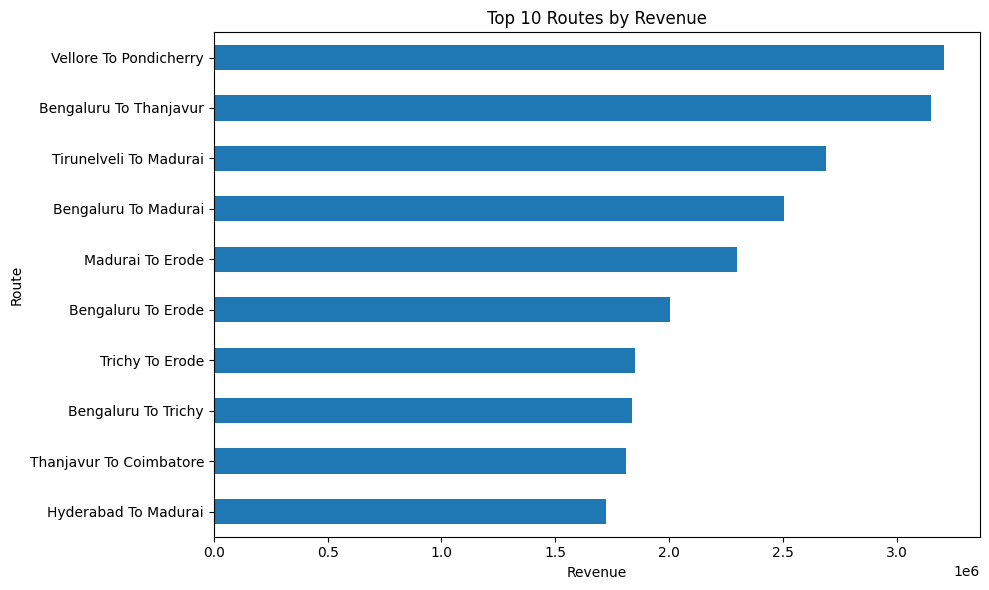

In [36]:
plt.figure(figsize=(10, 6))

top_revenue_routes.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Routes by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Route")

plt.tight_layout()

plt.show()

In [37]:
daily_bookings = (
    bookings
    .groupby("booking_date")
    .size()
)

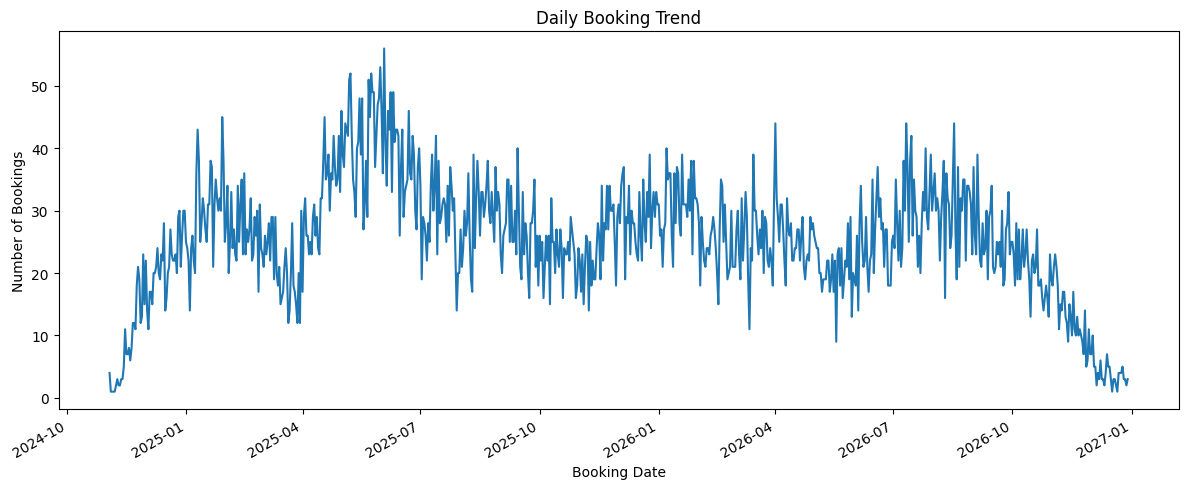

In [38]:
plt.figure(figsize=(12, 5))

daily_bookings.plot()

plt.title("Daily Booking Trend")
plt.xlabel("Booking Date")
plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.show()

In [39]:
daily_revenue = (
    bookings
    .groupby("booking_date")["total_amount"]
    .sum()
)

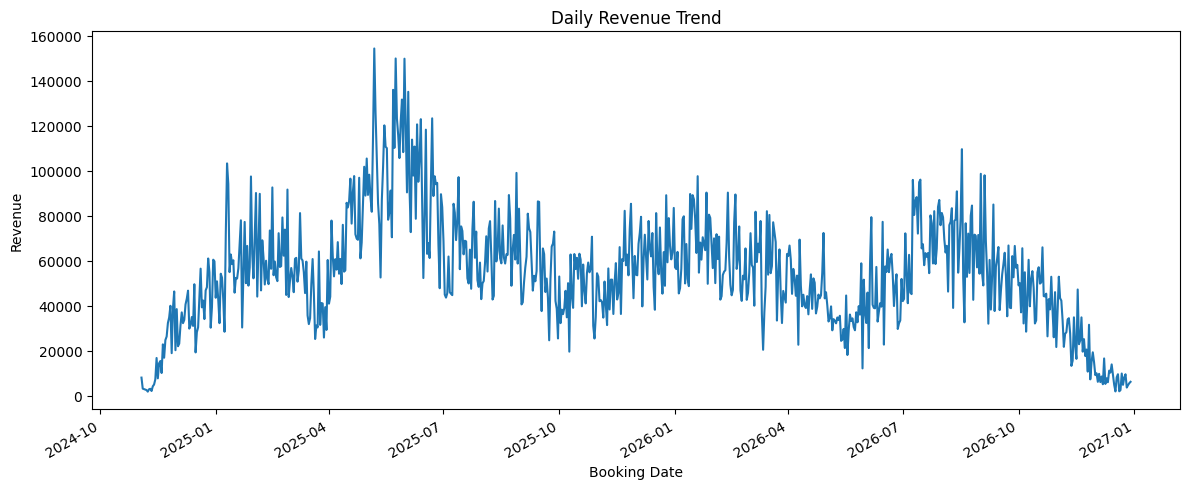

In [40]:
plt.figure(figsize=(12, 5))

daily_revenue.plot()

plt.title("Daily Revenue Trend")
plt.xlabel("Booking Date")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [41]:
customer_booking_counts = (
    bookings
    .groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

customer_booking_counts.head(10)

customer_id
CUST00347    14
CUST02247    12
CUST03737    12
CUST01672    11
CUST00821    11
CUST03976    11
CUST03648    11
CUST00485    11
CUST03114    11
CUST01609    11
dtype: int64

In [42]:
top_customers_revenue = (
    bookings
    .groupby("customer_id")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_revenue

customer_id
CUST01803    32945.91
CUST01612    32101.24
CUST04551    31796.49
CUST00922    31639.43
CUST01513    31406.07
CUST04572    31296.29
CUST04721    31087.51
CUST00729    30919.94
CUST03385    30855.56
CUST00821    30506.26
Name: total_amount, dtype: float64

In [43]:
cancelled = bookings[
    bookings["booking_status"] == "CANCELLED"
]

In [44]:
cancellation_rate = (
    len(cancelled) /
    len(bookings)
) * 100

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

Cancellation Rate: 13.26%


In [45]:
cancellation_by_payment = pd.crosstab(
    bookings["payment_method"],
    bookings["booking_status"]
)

cancellation_by_payment

booking_status,CANCELLED,CONFIRMED,PENDING
payment_method,,,
CARD,500,3244,203
CASH,543,3355,198
NETBANKING,552,3164,217
UPI,526,3246,201
WALLET,532,3325,194


In [46]:
numeric_columns = bookings[
    [
        "seat_count",
        "ticket_price",
        "total_amount"
    ]
]

correlation = numeric_columns.corr()

correlation

,seat_count,ticket_price,total_amount
seat_count,1.000000,-0.011611,0.744664
ticket_price,-0.011611,1.000000,0.568726
total_amount,0.744664,0.568726,1.000000


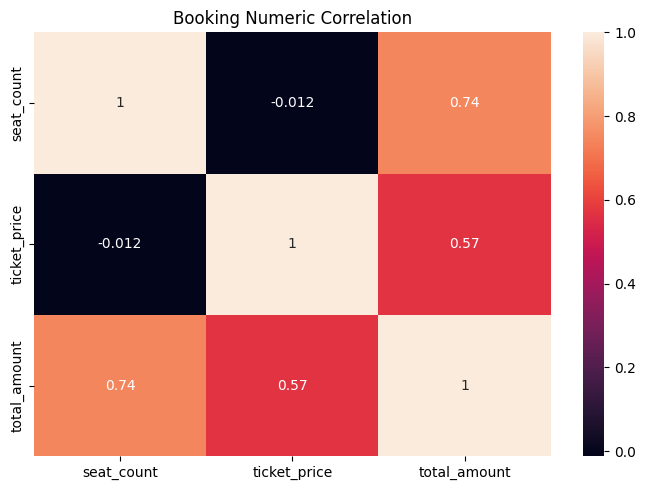

In [47]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Booking Numeric Correlation")

plt.tight_layout()

plt.show()